In [1]:
import os
import sys
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Project root = parent of current working directory (run notebook from Data-preprocess)
_script_dir = os.getcwd()
_project_root = os.path.dirname(_script_dir)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)
if _script_dir not in sys.path:
    sys.path.insert(0, _script_dir)

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.mt2d_inv.MTinv_2d_weighted_cost import MT2DInverterWeightedCost
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 
# Smaller grid (zn_n_cells, yn_n_cells) is set in "Load or convert data"; use cuda if grid fits GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
from __future__ import annotations

import sys
import torch
from pathlib import Path
from src.mt2d_inv.prepare_data_class import PrepareData

# ================= USER PARAMETERS =================
EDI_DIR = "Cascadia-CAFE-profile-3"

# Inversion frequency band (Hz)
FREQ_MIN_HZ = 1e-5
FREQ_MAX_HZ = 1e-1
MAG_DECLINATION_DEG = 15.0  # east positive, same convention as PrepareData.compute_strike

# Fixed regional strike (true north, deg). Profile + tensor rotation use this; no strike estimate.
STRIKE_TRUE_DEG = 0.0
# Magnetic strike for rotate_all: consistent with true = wrap_deg_180(magnetic + declination)
STRIKE_MAGNETIC_DEG = float(STRIKE_TRUE_DEG - MAG_DECLINATION_DEG)

# Data cleaning ON (OOQ + rel_err + skew + neighbor-spike); all stations/EDI files still loaded.
prep = PrepareData(
    edi_dir=EDI_DIR,
    mag_declination_deg=MAG_DECLINATION_DEG,
    edi_impedance_unit="mv/km/nt",
    freq_min_hz=FREQ_MIN_HZ,
    freq_max_hz=FREQ_MAX_HZ,
    clean_data = False
)

device = "cuda" if torch.cuda.is_available() else "cpu"

freqs_t, stations_t, data_dict = prep.run_all_simple(
    rotate=True,
    strike_true_deg=STRIKE_TRUE_DEG,
    strike_magnetic_deg=STRIKE_MAGNETIC_DEG,
    device=device,
)
print(f"[pipeline] Fixed strike (true N) = {STRIKE_TRUE_DEG}°, rotation (mag) = {STRIKE_MAGNETIC_DEG:.2f}°")
print(f"[pipeline] Stations: {len(prep.mt_objects)} (all EDI kept; cleaning only masks bad points)")

Using EDI_DIR = Cascadia-CAFE-profile-3
Found 24 EDI files
[PrepareData] Converted impedance units to ohms for 24/24 stations (edi_impedance_unit='mv/km/nt').
[PrepareData] Loaded Tipper for 15/24 stations (90° strike check enabled).
[PrepareData] Skipped frequency harmonization. Stations retain their original frequencies.
Estimated regional strike (magnetic reference) = -16.26274842248452
Magnetic declination (manual, east positive) = 15.000 deg
Estimated regional strike (true north reference) = -1.2627484224845205
All stations rotated by -15.00 degrees
[PrepareData] Exported Tensor shape: Frequencies=20, Stations=24
[pipeline] Fixed strike (true N) = 0.0°, rotation (mag) = -15.00°
[pipeline] Stations: 24 (all EDI kept; cleaning only masks bad points)


In [3]:
# 1. 垂向网格
# ==========================================
nza = 10
# 空气层：保持指数增长，越靠近地表越密
z_air = -np.logspace(np.log10(10), np.log10(50000), nza) # 10m 到 50km
z_air = np.flip(z_air) # 翻转，从-50km到-10m
z_air = np.append(z_air, 0) # 加上地表 0

nz = 80
z_sub = np.logspace(np.log10(10), np.log10(300000), nz)
zn = np.concatenate([z_air[:-1], np.array([0]), z_sub])

# ==========================================
# 2. 横向网格 (Horizontal Grid, y) - 核心修改
# ==========================================
# 中心区（关注区）
y_center = np.linspace(-250000, 250000, 201) 

# 两侧扩展区：向外指数稀疏消除侧向边界反射
y_left = -np.logspace(np.log10(255000), np.log10(950000), 20)
y_right = np.logspace(np.log10(255000), np.log10(950000), 20)
y_left = np.flip(y_left)

yn = np.concatenate([y_left, y_center, y_right])

print(f"新的网格统计:")
print(f" - 垂向第一层厚度: {zn[nza+1] - zn[nza]:.1f} m")
print(f" - 最大深度: {zn[-1]/1000:.1f} km")
print(f" - 中心区横向分辨率: {y_center[1] - y_center[0]:.1f} m")
print(f" - 网格总数: {len(zn)-1} x {len(yn)-1}")


新的网格统计:
 - 垂向第一层厚度: 10.0 m
 - 最大深度: 300.0 km
 - 中心区横向分辨率: 2500.0 m
 - 网格总数: 90 x 240


In [4]:
# 3) Inverter: TE + TM (xy + yx); adjust te_weight / tm_weight if needed
inv = MT2DInverterWeightedCost(
    yn=torch.as_tensor(yn, dtype=torch.float64, device=device),
    zn=torch.as_tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs_t,
    stations=stations_t,
    device=device,
    te_weight=3.0,
    tm_weight=1.0,
    data_loss_scale =6000
)
inv.load_obs_data(data_dict, noise_floor=0.2)
w_d_point = inv.update_ot_w_d_per_point_from_noise(
    w_d_scale=[1,1,1,1],
    normalize="mean",
 )


✓ Random seed set: 42
✓ Sinkhorn (custom cost): blur=0.01, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.01, scale=0.9, reach=None
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.2665
   phi(normalized) noise mean: 0.2643
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.2632
   phi(normalized) noise mean: 0.2619
✓ 2D data error propagation completed
Computing data weights (Target Noise: 20.0%)
  - Resistivity Error Floor: 20.0%
  - Phase Error Floor:       5.720 deg
✓ MSE data weights normalized (mean): scale=4.462655e+00
✓ Observed data loaded from file
✓ Sinkhorn (custom cost): blur=0.01, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=tensor(356, 4)@cuda, blur=0.01, scale=0.9, reach=None


✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


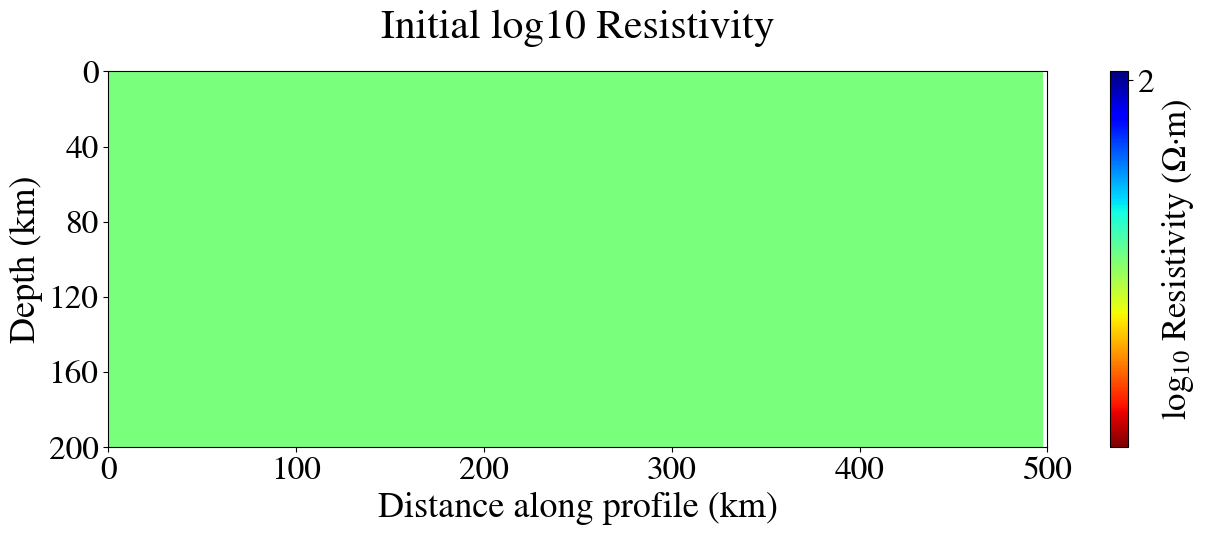

✓ Optimizer: AdamW, lr=0.7, weight_decay=0.0
Epoch 1/100 [   1.0%]
  Elapsed: 0:00:10 | Remaining: ~0:16:13 | ETA: 08:55:42
  Epoch time: 9.83s | Avg: 9.83s
  Total: 5.8248e+02 | Data(6dot): 5.8248e+02
  [Cost weights] w_s=1.000, w_f=1.000, w_d=tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000],
        ...,
        [1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]], device='cuda:0')
  Misfit(RMS χ²): 7.701 | Rough: 0.00e+00 | Lam: 1.0000000
  GradNorms: |g_d|=1.169e-01 | |λ·g_m|=1.000e-12
 [Auto-Lambda] Epoch 3: Adjusted 1.00e+00 -> 2.51e-02 (ratio=8.636e-03)
 [Auto-Lambda] Epoch 6: Adjusted 2.51e-02 -> 4.89e-03 (ratio=1.293e-01)
 [Auto-Lambda] Epoch 9: Adjusted 4.89e-03 -> 1.72e-03 (ratio=2.704e-01)
Epoch 11/100 [  11.0%]
  Elapsed: 0:01:47 | Remaining: ~0:14:19 | ETA: 08:55:25
  Epoch time: 9.66s | Avg: 9.66s
  Total: 7.2883e+01 | Data(6dot): 5

In [5]:
inv.set_forward_operator()
inv.initialize_model(initial_sigma=0.03)

inv.plot_initial_model(
    clip_to_stations=True,
    ylim=[200, 0],
    profile_axis_width_km = 500
)

final_sigma = inv.run_inversion(
    n_epochs=100,
    mode="6dot",
    progress_interval=10,
    current_lambda=1,
    use_adaptive_lambda=True,
    lr=0.7,
    rms_chi2_stop = 1.4,
    update_interval=3,
    norm_type="L2",
    alpha=0.8,
    use_depth_weights=True,
    use_ot_weights=True,
    enable_blur_anneal=True,
    warmup_epochs =0
)

print("done; sigma range:", final_sigma.min().item(), final_sigma.max().item())


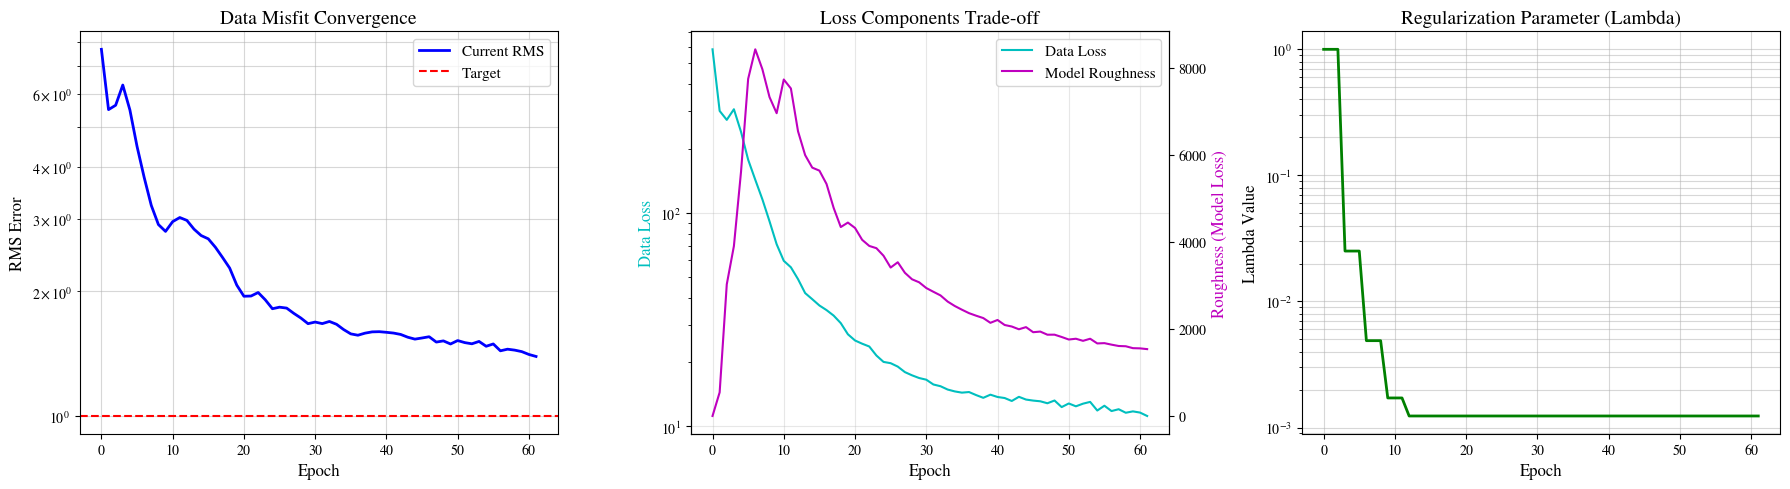

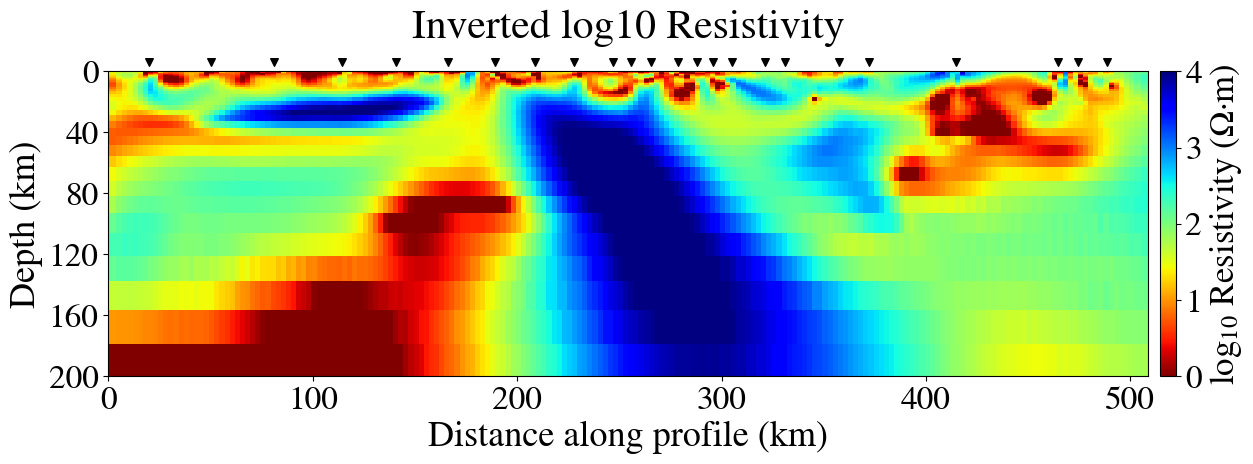

6.81292e-05 0.1


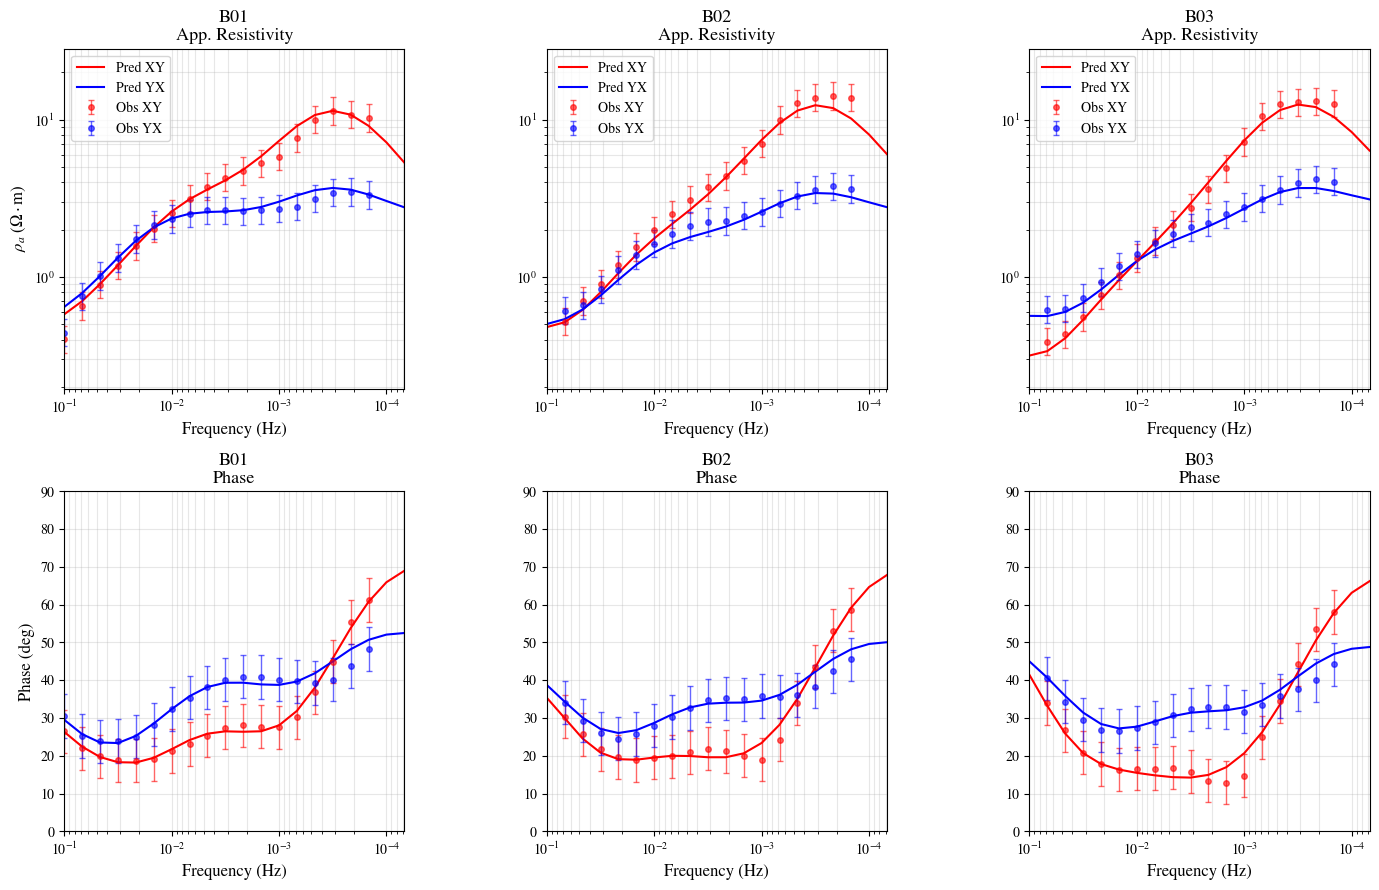

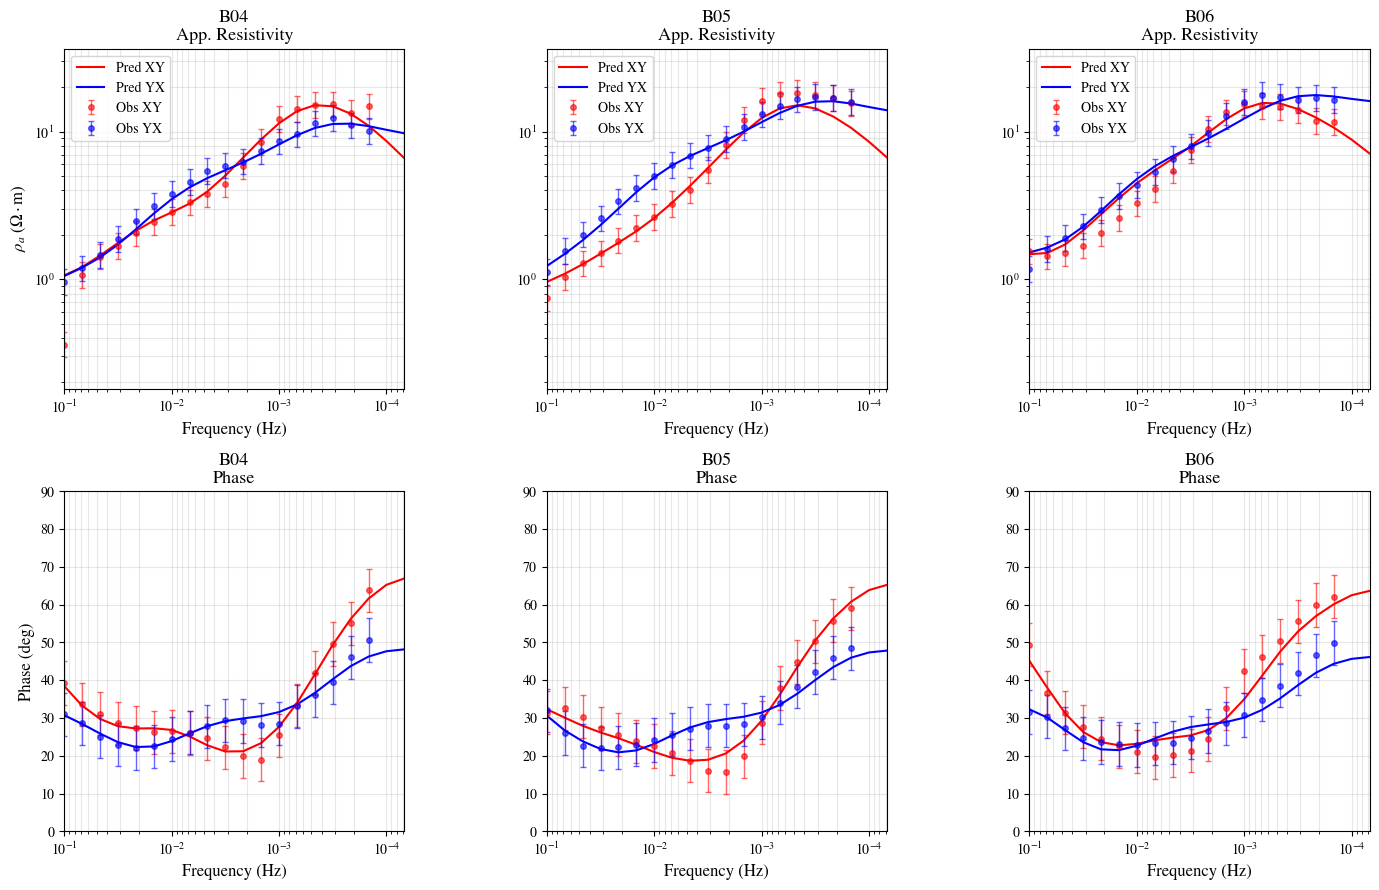

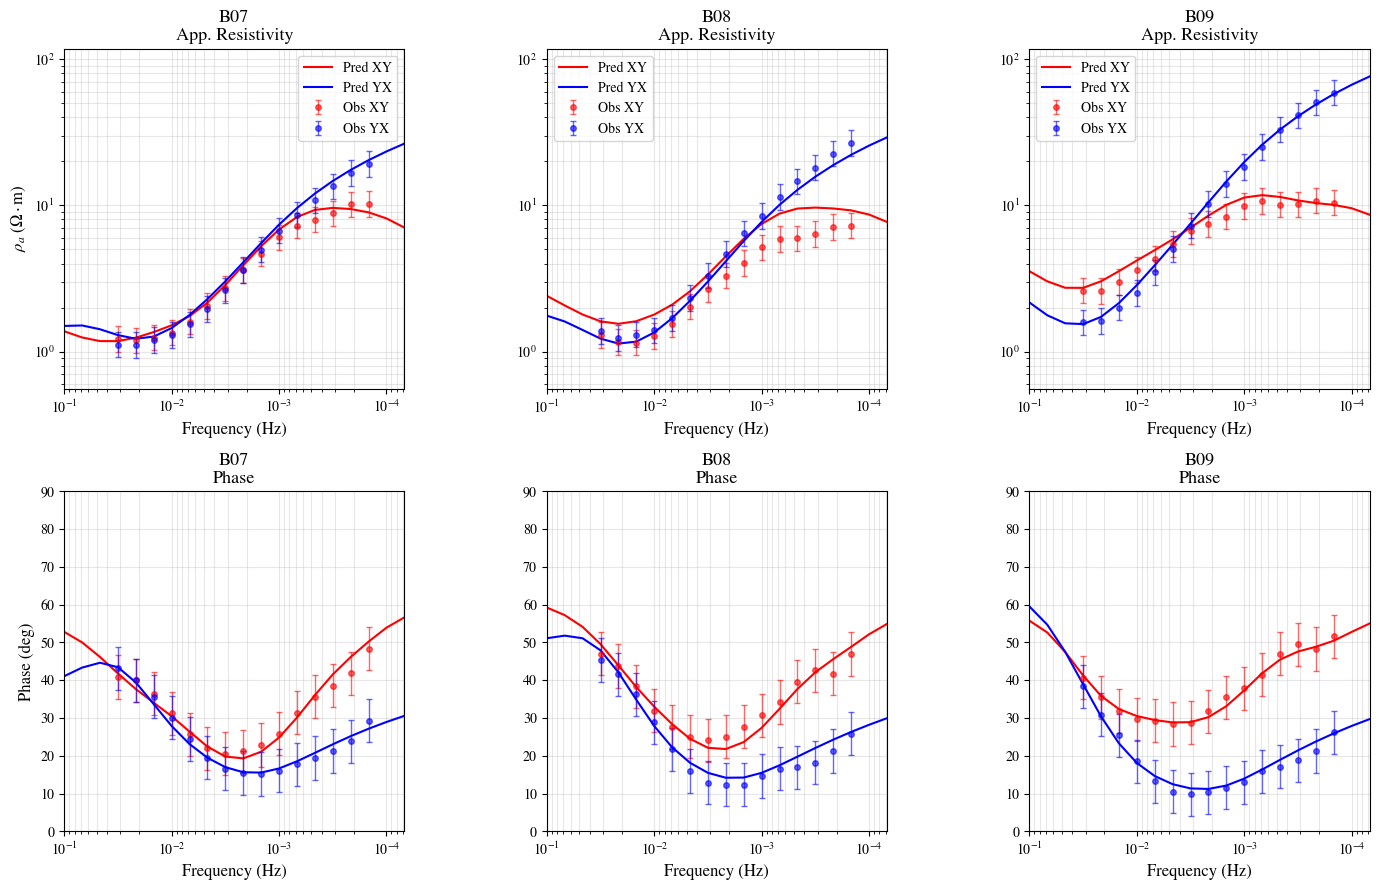

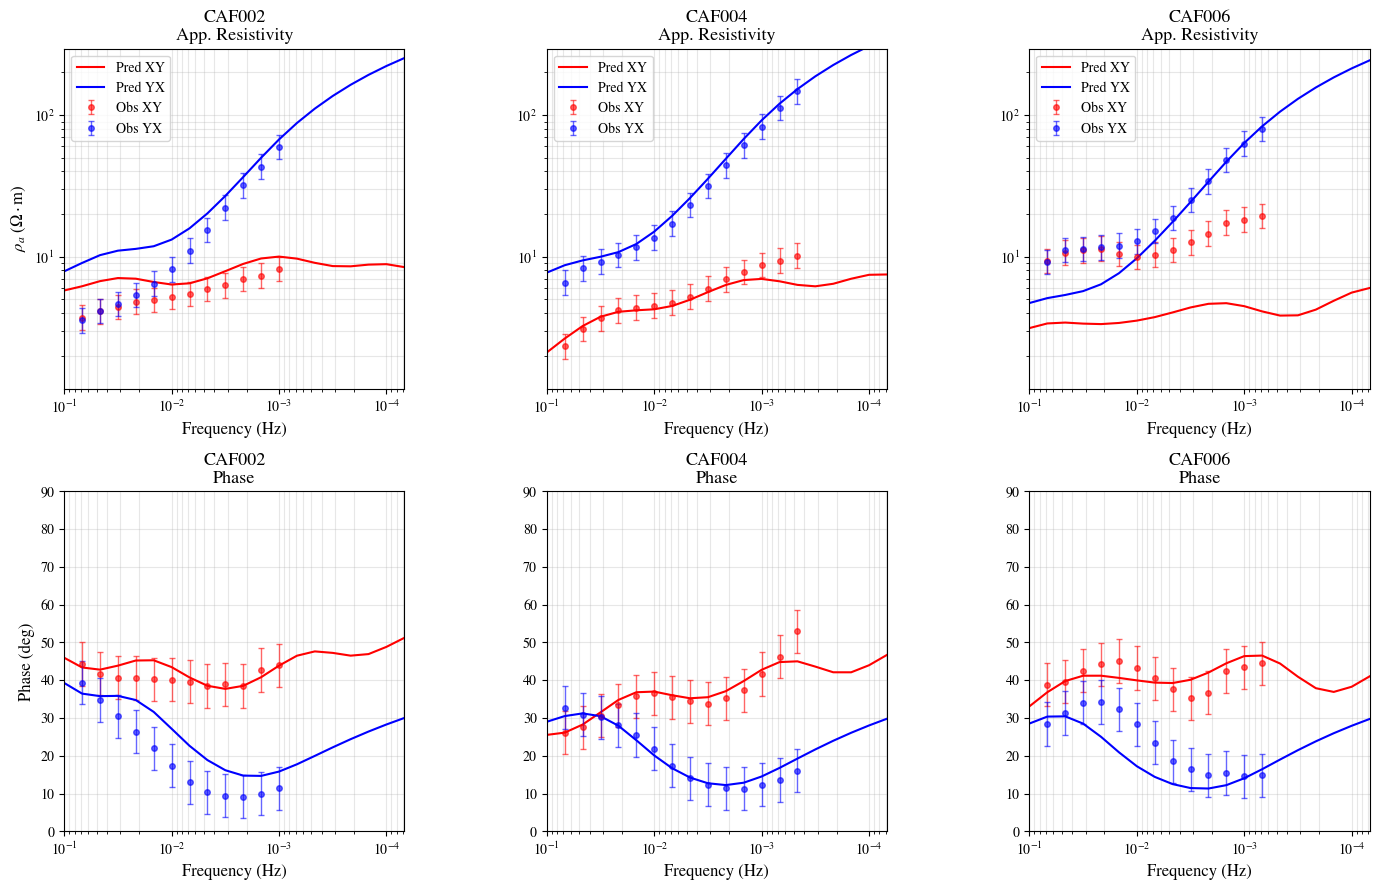

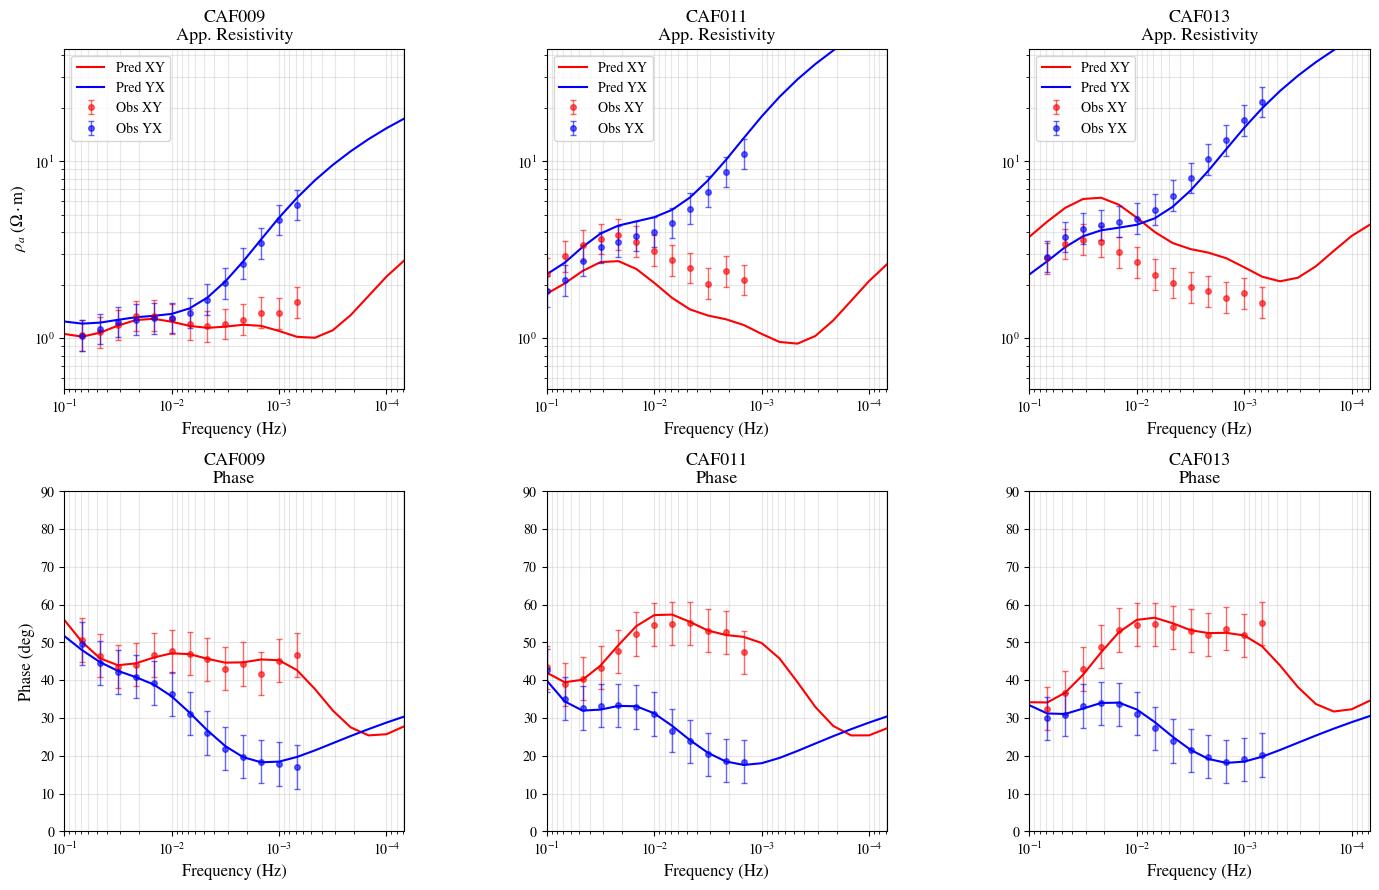

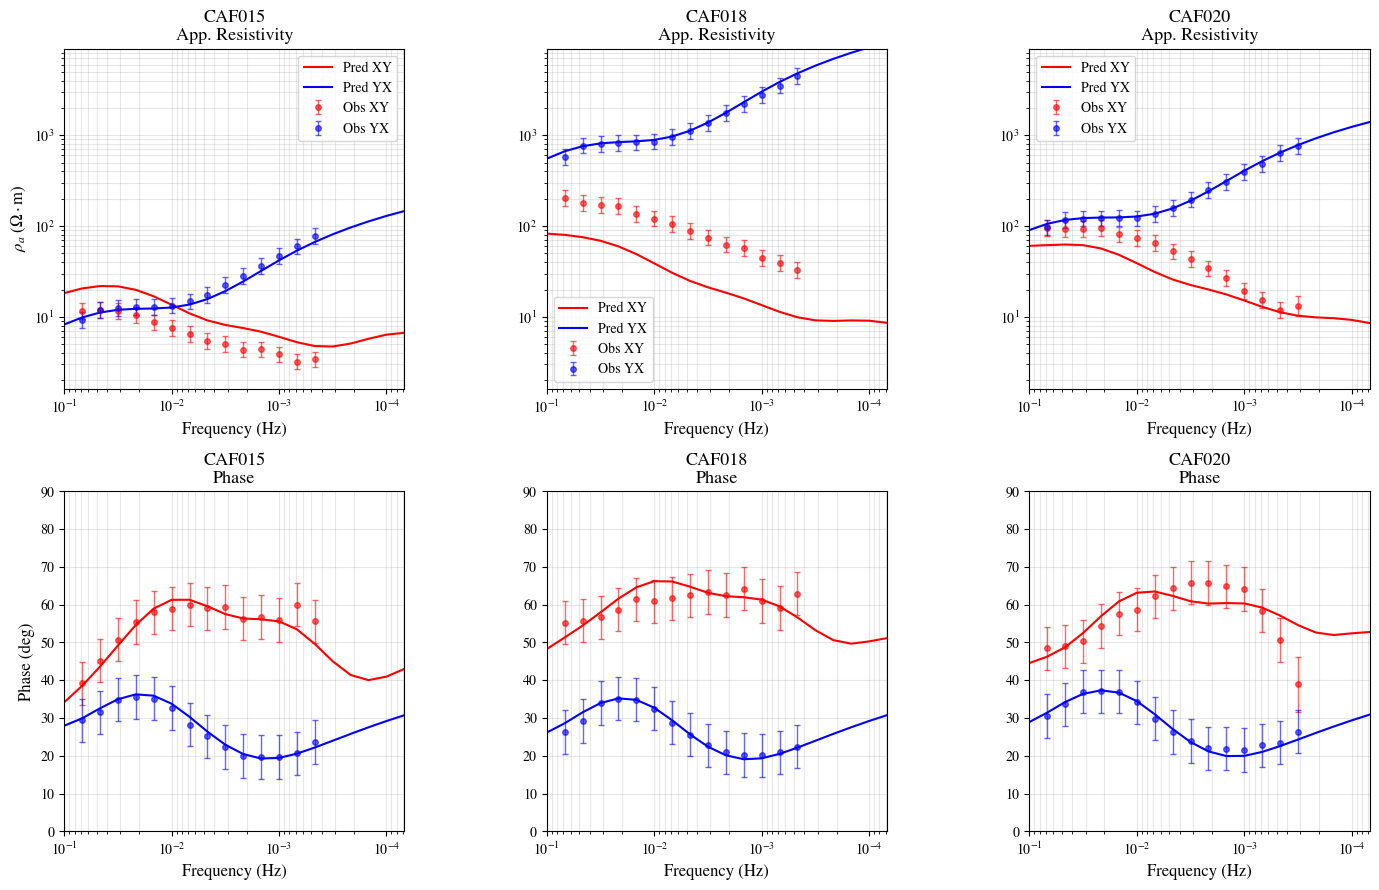

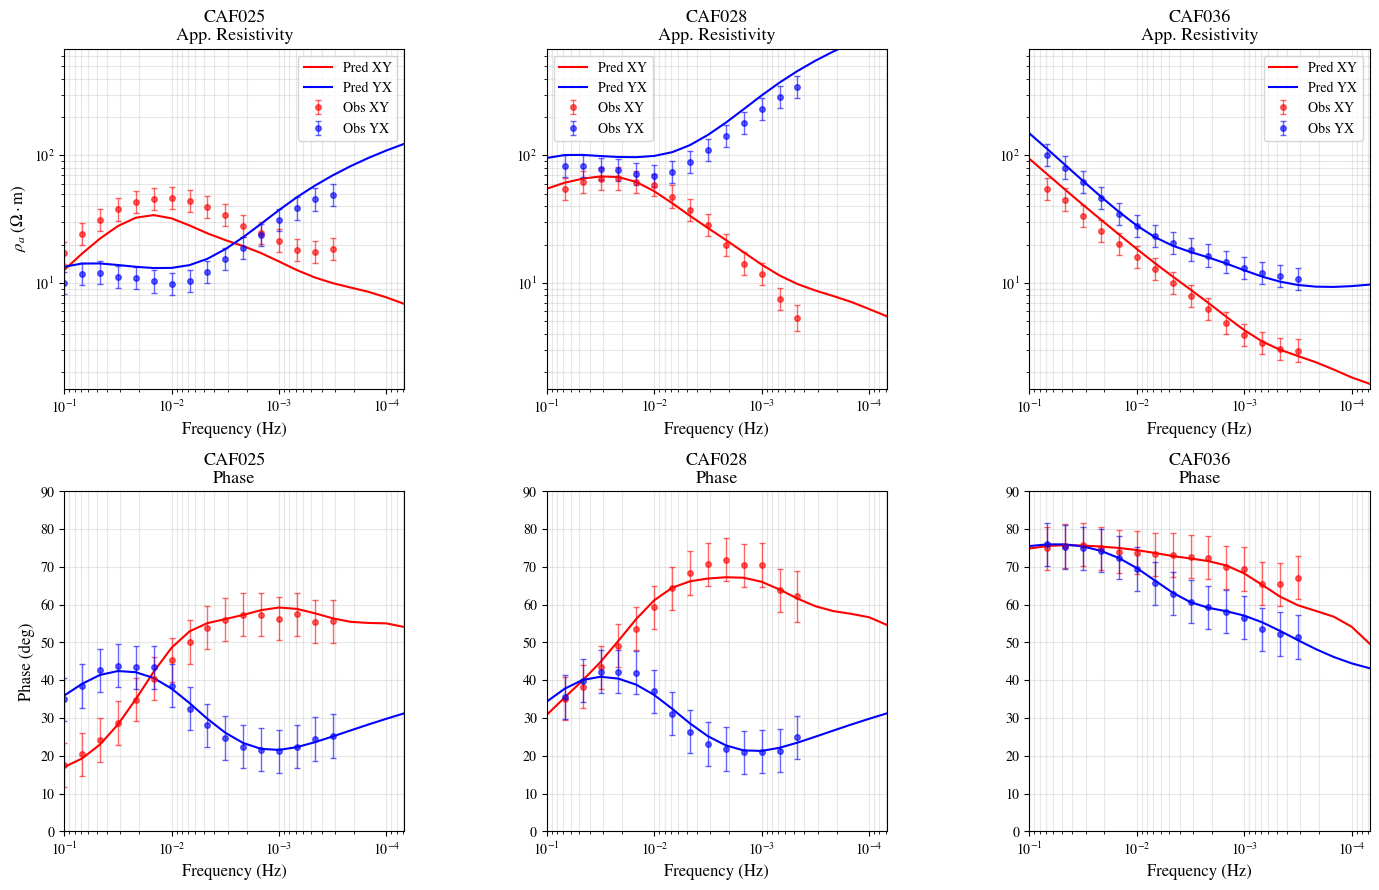

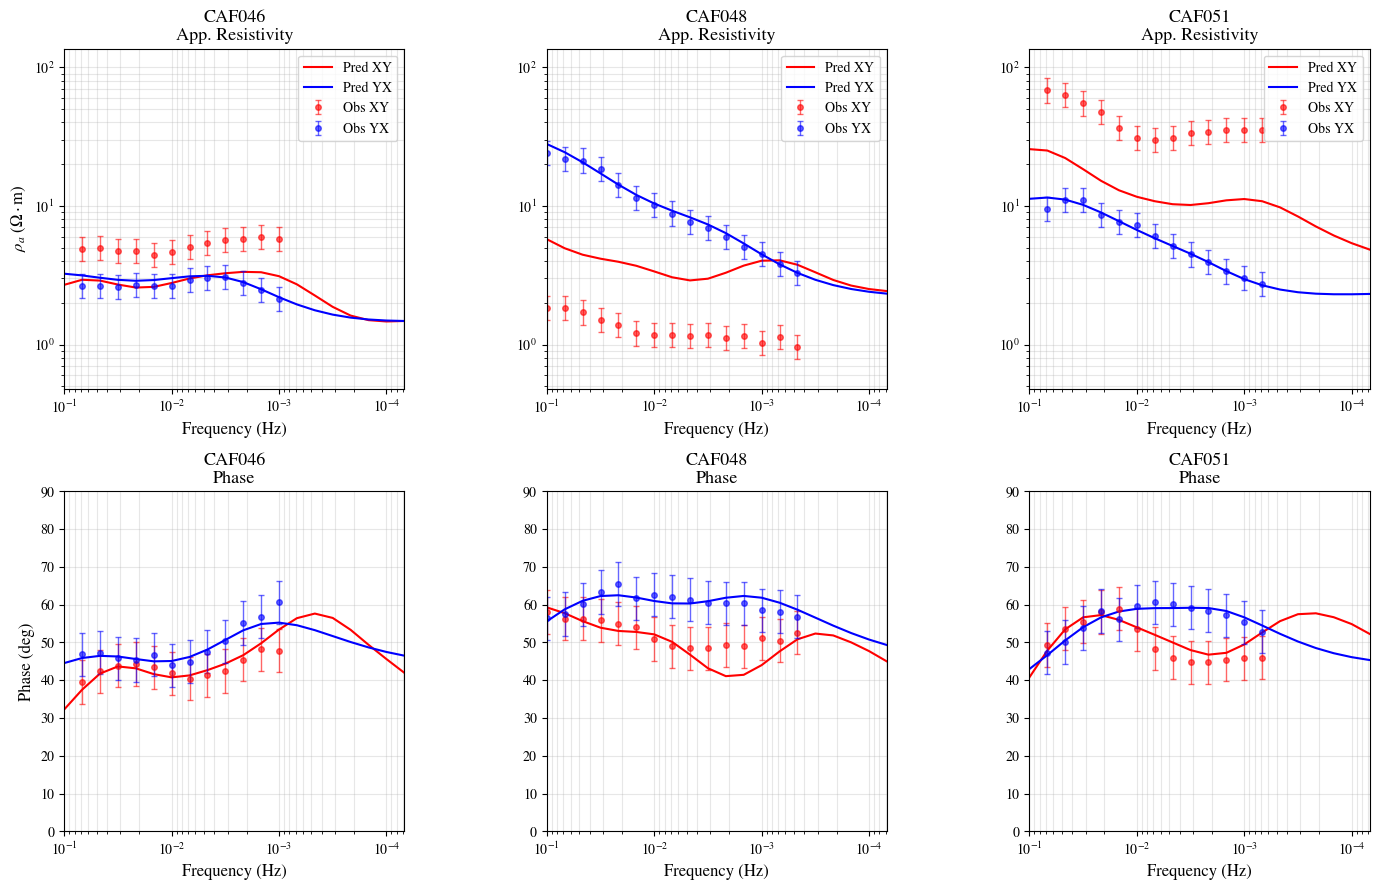

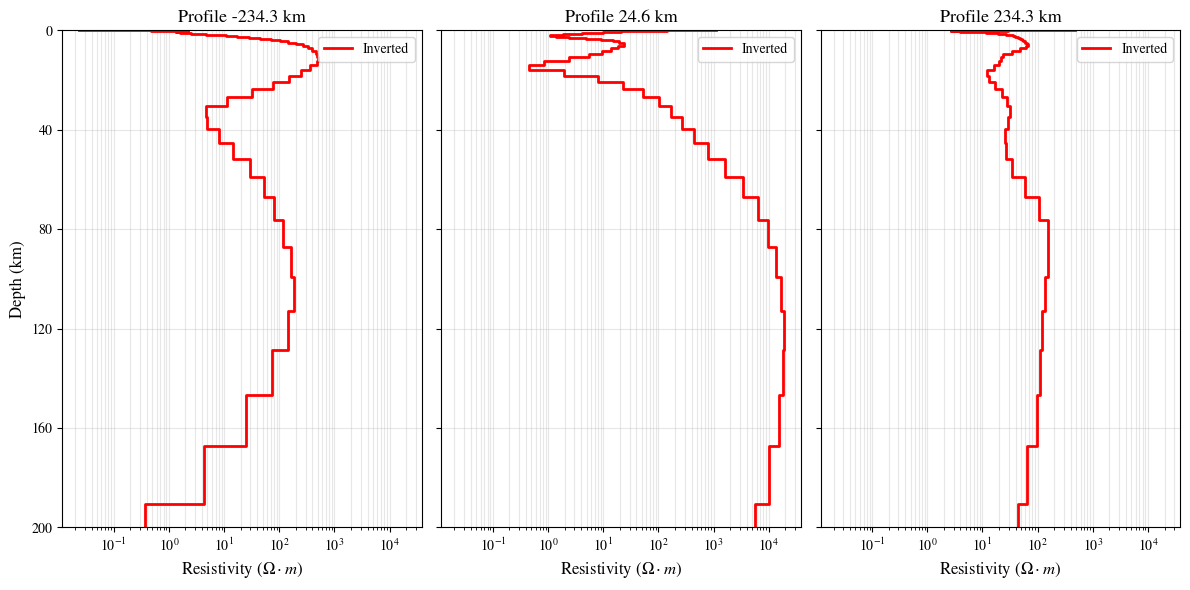

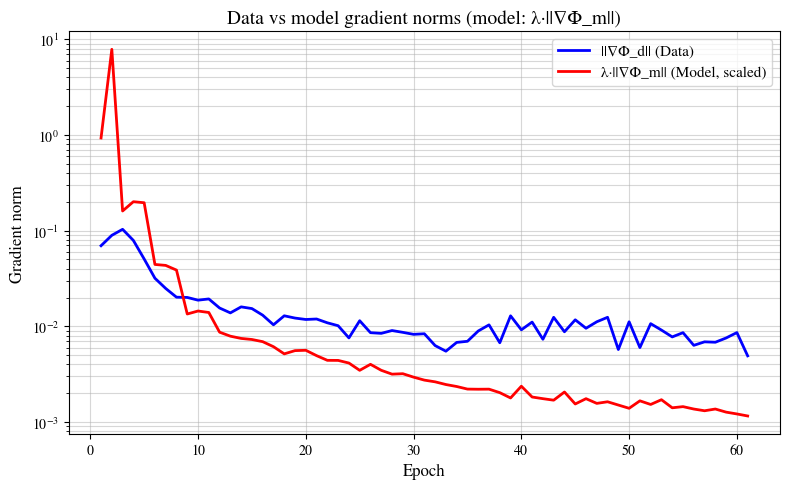

In [6]:
# OT output
inv.plot_loss_history()

inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[200, 0],
    profile_extend_km=20,
    vmin = 0, vmax = 4
)

print(freqs_t.min().item(), freqs_t.max().item())

# Plot data fitting for ALL stations (in batches to keep figures readable)
batch_size = 3  # increase/decrease if you want more/less stations per figure
n_stations = len(inv.stations)
for start in range(0, n_stations, batch_size):
    end = min(start + batch_size, n_stations)
    station_indices = list(range(start, end))
    inv.plot_data_fitting(station_indices=station_indices)

inv.plot_1d_profiles(depth_limit_km=200)
inv.plot_gradient_history()


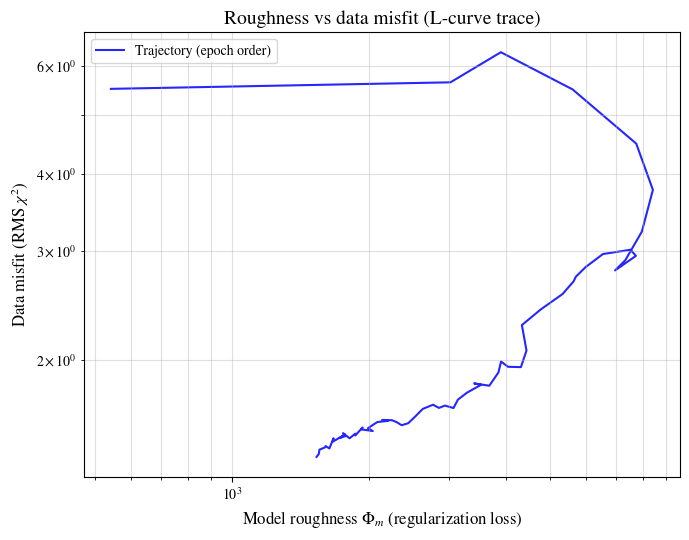

In [7]:
# L-curve: 横轴 = 模型粗糙度 Φ_m，纵轴 = 数据项 RMS χ²
inv.plot_roughness_misfit_curve()